In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        pass


In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import shutil

In [17]:
import os

data_dir = "./dataset/"  # Update with your correct path
drowsy_dir = os.path.join(data_dir, 'drowsy')  # Match exact folder name
non_drowsy_dir = os.path.join(data_dir, 'non_drowsy')  # Match exact folder name

In [18]:
# Check if directories exist
if not os.path.exists(drowsy_dir):
    raise FileNotFoundError(f"Error: Drowsy folder not found at {drowsy_dir}")

if not os.path.exists(non_drowsy_dir):
    raise FileNotFoundError(f"Error: Non-Drowsy folder not found at {non_drowsy_dir}")

print("Dataset directories exist and are ready to use.")


Dataset directories exist and are ready to use.


In [19]:
# Create train, val, test directories
output_dir = "prepared_data"
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")


In [20]:
for split in [train_dir, val_dir, test_dir]:
    for category in ["drowsy", "non_drowsy"]:
        os.makedirs(os.path.join(split, category), exist_ok=True)


In [21]:
# Helper function to split and copy files
def split_and_copy(source_dir, target_dirs, split_ratios):
    filenames = os.listdir(source_dir)
    train, test = train_test_split(filenames, test_size=split_ratios[1] + split_ratios[2], random_state=42)
    val, test = train_test_split(test, test_size=split_ratios[2] / (split_ratios[1] + split_ratios[2]), random_state=42)
    
    splits = {"train": train, "val": val, "test": test}
    for split_name, files in splits.items():
        split_path = target_dirs[split_name]
        category_name = os.path.basename(source_dir)  # 'Drowsy' or 'Non Drowsy'
        category_path = os.path.join(split_path, category_name.lower().replace(" ", "_"))  # Convert to lowercase and underscores
        # Create subdirectory if it doesn't exist
        os.makedirs(category_path, exist_ok=True)
        
        for file in files:
            shutil.copy(os.path.join(source_dir, file), os.path.join(category_path, file))

In [22]:
# Split the data
split_and_copy(drowsy_dir, {"train": train_dir, "val": val_dir, "test": test_dir}, [0.7, 0.2, 0.1])
split_and_copy(non_drowsy_dir, {"train": train_dir, "val": val_dir, "test": test_dir}, [0.7, 0.2, 0.1])

In [23]:
# ImageDataGenerator for data loading and augmentation
train_datagen = ImageDataGenerator(rescale=1.0/255.0, rotation_range=20, zoom_range=0.15, width_shift_range=0.2,
                                   height_shift_range=0.2, shear_range=0.15, horizontal_flip=True, fill_mode="nearest")
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

Found 29254 images belonging to 2 classes.
Found 8359 images belonging to 2 classes.


In [24]:
# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

In [25]:
# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

model = Model(inputs=base_model.input, outputs=output)


In [26]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10, steps_per_epoch=train_generator.samples//train_generator.batch_size, validation_steps=val_generator.samples//val_generator.batch_size)

Epoch 1/10


914/914 [==============================] - 1016s 1s/step - loss: 0.6421 - accuracy: 0.6471 - val_loss: 0.4911 - val_accuracy: 0.8209
Epoch 2/10
914/914 [==============================] - 662s 724ms/step - loss: 0.5133 - accuracy: 0.7432 - val_loss: 0.3934 - val_accuracy: 0.8672
Epoch 3/10
914/914 [==============================] - 654s 715ms/step - loss: 0.4523 - accuracy: 0.7874 - val_loss: 0.3204 - val_accuracy: 0.9115
Epoch 4/10
914/914 [==============================] - 649s 710ms/step - loss: 0.4171 - accuracy: 0.8091 - val_loss: 0.2839 - val_accuracy: 0.9225
Epoch 5/10
914/914 [==============================] - 646s 707ms/step - loss: 0.3842 - accuracy: 0.8250 - val_loss: 0.2474 - val_accuracy: 0.9297
Epoch 6/10
914/914 [==============================] - 642s 702ms/step - loss: 0.3589 - accuracy: 0.8397 - val_loss: 0.2229 - val_accuracy: 0.9382
Epoch 7/10
914/914 [==============================] - 646s 706ms/step - loss: 0.3383 - accuracy: 0.8520 - val_loss: 0.1947 -

In [28]:
# Save model
model.save("drowsiness_detection_model.h5")

C:\Users\91962\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
# Evaluate on test set
test_generator = val_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Found 4180 images belonging to 2 classes.
131/131 [==============================] - 142s 1s/step - loss: 0.1659 - accuracy: 0.9486
Test Accuracy: 94.86%


In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [31]:
# Load the trained model
model_path = "./drowsiness_detection_model.h5"  # Replace with the path to your saved model
model = tf.keras.models.load_model(model_path)

In [32]:
# Define a function to make predictions
def predict_image(image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224))  # Match input size of the model
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values to [0, 1]
    # Make a prediction
    prediction = model.predict(img_array)[0][0]

    # Map the prediction to the correct label
    if prediction >= 0.5:
        label = "Non-Drowsy"  # Prediction corresponds to class label 1
    else:
        label = "Drowsy"  # Prediction corresponds to class label 0

    # Display the image with the predicted label
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {label}")
    plt.show()

    return label

1/1 [==============================] - 0s 114ms/step


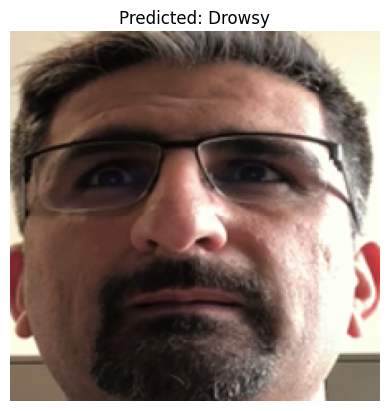

Prediction: Drowsy
1/1 [==============================] - 0s 123ms/step


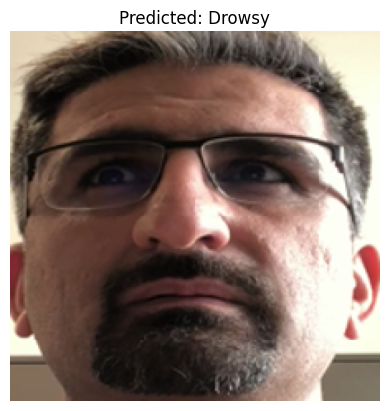

Prediction: Drowsy
1/1 [==============================] - 0s 137ms/step


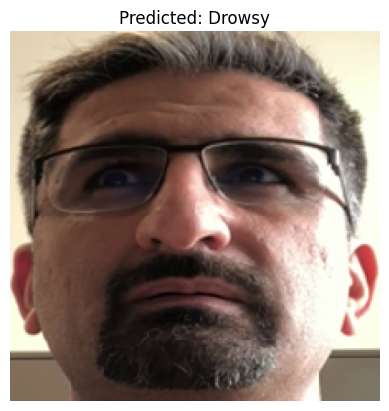

Prediction: Drowsy
Test image not found: ./dataset/Non Drowsy/a0072.png
1/1 [==============================] - 0s 117ms/step


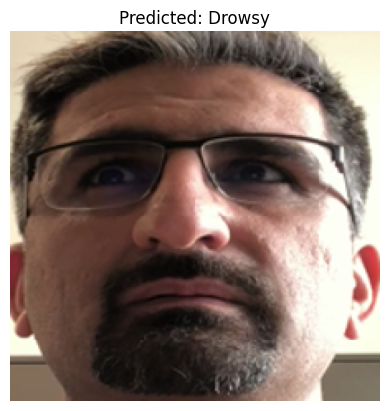

Prediction: Drowsy
Test image not found: ./dataset/Non Drowsy/a0042.png
Test image not found: ./dataset/Non Drowsy/a0011.png
Test image not found: ./dataset/Non Drowsy/a0028.png
1/1 [==============================] - 0s 149ms/step


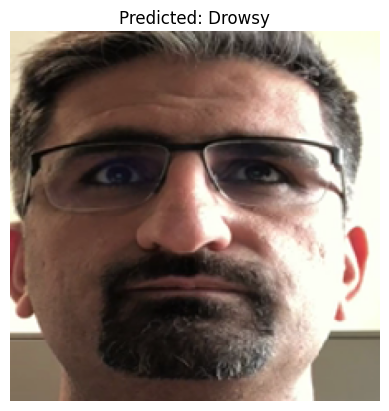

Prediction: Drowsy
Test image not found: ./dataset/Non Drowsy/a0089.png
Test image not found: ./dataset/Non Drowsy/a0033.png


In [35]:
# Test the function with an image from the test dataset
for i in range(20,31):
    
    test_image_path = f"/kaggle/input/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A00{random.randint(10,99)}.png" if random.randint(0,100)%2==0 else f"/kaggle/input/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Non Drowsy/a00{random.randint(10,99)}.png"  # Replace with a test image path
    if os.path.exists(test_image_path):
        result = predict_image(test_image_path)
        print(f"Prediction: {result}")
    else:
        print(f"Test image not found: {test_image_path}")

In [40]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
from tkinter import Tk, filedialog

# Load the trained model (update the path if needed)
model_path = "./drowsiness_detection_model.h5"  # Update with your model path
model = load_model(model_path)

# Function to make predictions
def predict_image(image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224))  # Match model input size
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values to [0, 1]

    # Make a prediction
    prediction = model.predict(img_array)[0][0]

    # Map the prediction to the correct label
    label = "Non-Drowsy" if prediction >= 0.5 else "Drowsy"

    # Display the image with the predicted label
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {label}")
    plt.show()

    return label

# Function to select an image and predict
def select_image():
    Tk().withdraw()  # Hide the root window
    file_path = filedialog.askopenfilename(title="Select an Image", filetypes=[("Image Files", "*.jpg;*.png;*.jpeg")])
    
    if file_path:
        print(f"Processing: {file_path}")
        label = predict_image(file_path)
        print(f"Prediction: {label}")



Processing: C:/Users/91962/OneDrive/Pictures/Camera Roll/WIN_20230122_15_28_21_Pro.jpg
1/1 [==============================] - 1s 819ms/step


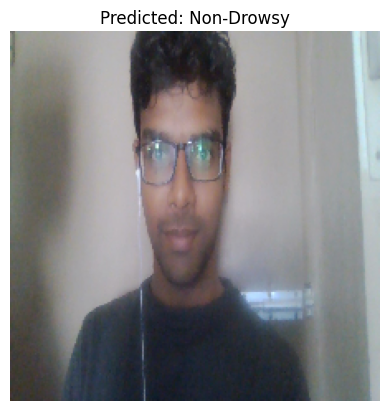

Prediction: Non-Drowsy


In [41]:
# Run the function
select_image()


In [42]:
# Run the function
select_image()